In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

student_mat = pd.read_csv('donnees/student-mat.csv')
student_por = pd.read_csv('donnees/student-por.csv')
print(f'Dataset : {student_mat.shape[0]} élèves, {student_mat.shape[1]} variables')


Dataset : 395 élèves, 33 variables


In [13]:
df_higher_no = student_mat[student_mat['higher'] == 'no']
print(f"Nombre d'élèves avec higher='no' : {len(df_higher_no)}")


Nombre d'élèves avec higher='no' : 20


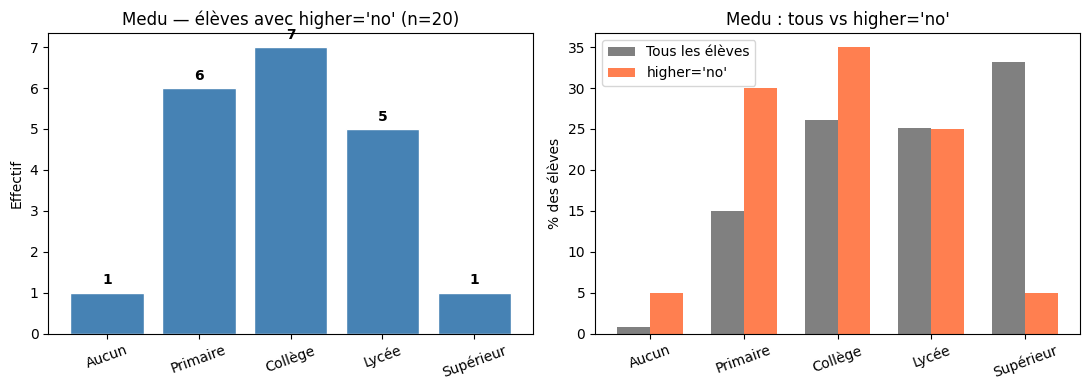

Distribution Medu (higher='no') :
Medu
0    1
1    6
2    7
3    5
4    1
Name: count, dtype: int64
Nombre d'élèves avec higher='no' : 20


In [14]:
edu_labels = {0:'Aucun', 1:'Primaire', 2:'Collège', 3:'Lycée', 4:'Supérieur'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df_higher_no['Medu'].value_counts().sort_index()
axes[0].bar([edu_labels[i] for i in vc.index], vc.values, color='steelblue', edgecolor='white')
axes[0].set_title(f"Medu — élèves avec higher='no' (n={len(df_higher_no)})")
axes[0].set_ylabel('Effectif')
axes[0].tick_params(axis='x', rotation=20)
for j, v in enumerate(vc.values):
    axes[0].text(j, v + 0.2, str(v), ha='center', fontweight='bold')

# Comparaison avec la population globale
vc_all = student_mat['Medu'].value_counts(normalize=True).sort_index() * 100
vc_no  = df_higher_no['Medu'].value_counts(normalize=True).sort_index() * 100
x = np.arange(5)
width = 0.35
axes[1].bar(x - width/2, [vc_all.get(i, 0) for i in range(5)], width, label='Tous les élèves', color='gray')
axes[1].bar(x + width/2, [vc_no.get(i, 0) for i in range(5)], width, label="higher='no'", color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels([edu_labels[i] for i in range(5)], rotation=20)
axes[1].set_ylabel('% des élèves')
axes[1].set_title('Medu : tous vs higher=\'no\'')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Distribution Medu (higher='no') :")
print(vc)
df_higher_no = student_mat[student_mat['higher'] == 'no']
print(f"Nombre d'élèves avec higher='no' : {len(df_higher_no)}")


Nombre d'élèves avec higher='no' : 69


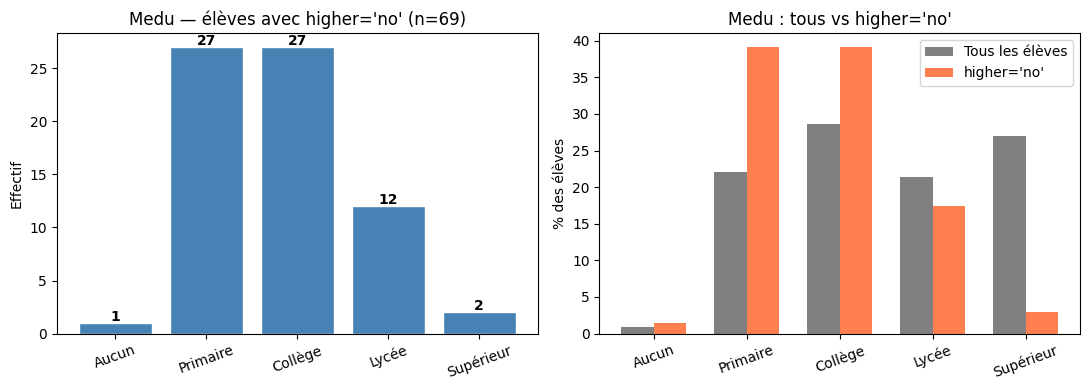

Distribution Medu (higher='no') :
Medu
0     1
1    27
2    27
3    12
4     2
Name: count, dtype: int64


In [15]:
df_higher_no_por = student_por[student_por['higher'] == 'no']
print(f"Nombre d'élèves avec higher='no' : {len(df_higher_no_por)}")


edu_labels = {0:'Aucun', 1:'Primaire', 2:'Collège', 3:'Lycée', 4:'Supérieur'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df_higher_no_por['Medu'].value_counts().sort_index()
axes[0].bar([edu_labels[i] for i in vc.index], vc.values, color='steelblue', edgecolor='white')
axes[0].set_title(f"Medu — élèves avec higher='no' (n={len(df_higher_no_por)})")
axes[0].set_ylabel('Effectif')
axes[0].tick_params(axis='x', rotation=20)
for j, v in enumerate(vc.values):
    axes[0].text(j, v + 0.2, str(v), ha='center', fontweight='bold')

# Comparaison avec la population globale
vc_all = student_por['Medu'].value_counts(normalize=True).sort_index() * 100
vc_no  = df_higher_no_por['Medu'].value_counts(normalize=True).sort_index() * 100
x = np.arange(5)
width = 0.35
axes[1].bar(x - width/2, [vc_all.get(i, 0) for i in range(5)], width, label='Tous les élèves', color='gray')
axes[1].bar(x + width/2, [vc_no.get(i, 0) for i in range(5)], width, label="higher='no'", color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels([edu_labels[i] for i in range(5)], rotation=20)
axes[1].set_ylabel('% des élèves')
axes[1].set_title('Medu : tous vs higher=\'no\'')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Distribution Medu (higher='no') :")
print(vc)
